# Level 3: Traditional ML Classifier for Profanity Detection

This notebook implements a scikit-learn text classifier using TF-IDF features and Logistic Regression.

## Approach
- **Train on**: All GameTox data EXCEPT the 200-message test subset
- **Test on**: Same 200-message subset used in Level 2 (for fair comparison)
- **Features**: TF-IDF (Term Frequency-Inverse Document Frequency)
- **Classifier**: Logistic Regression (recommended by scikit-learn docs)

## Key Learning Objectives
1. See what the model learns (feature weights)
2. Understand train/test methodology
3. Compare with rule-based (Level 1) and LLM (Level 2) approaches
4. Evaluate latency, cost, and accuracy tradeoffs

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
import pickle
import time
import csv

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All imports successful")

✓ All imports successful


## 2. Load GameTox Dataset

In [4]:
# Load full GameTox dataset
def load_gametox(csv_file):
    """Load GameTox data with binary labels (0=clean, 1=toxic)."""
    messages = []
    labels = []
    skipped = 0
    
    with open(csv_file, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            # Skip rows with empty or invalid labels
            if not row['label'] or row['label'].strip() == '':
                skipped += 1
                continue
            
            try:
                messages.append(row['message'])
                # Binary: 0=clean, 1=toxic (any non-zero label is toxic)
                label = int(float(row['label']))
                labels.append(0 if label == 0 else 1)
            except (ValueError, KeyError):
                skipped += 1
                continue
    
    if skipped > 0:
        print(f"⚠ Skipped {skipped} rows with missing/invalid labels")
    
    return messages, labels

# Load training data (full GameTox)
train_messages, train_labels = load_gametox('../data/GameTox/GameTox.csv')

print(f"✓ Loaded {len(train_messages):,} total messages from GameTox")
print(f"\nClass distribution:")
print(f"  Clean (0): {train_labels.count(0):,} ({train_labels.count(0)/len(train_labels)*100:.1f}%)")
print(f"  Toxic (1): {train_labels.count(1):,} ({train_labels.count(1)/len(train_labels)*100:.1f}%)")

⚠ Skipped 3 rows with missing/invalid labels
✓ Loaded 53,701 total messages from GameTox

Class distribution:
  Clean (0): 43,497 (81.0%)
  Toxic (1): 10,204 (19.0%)


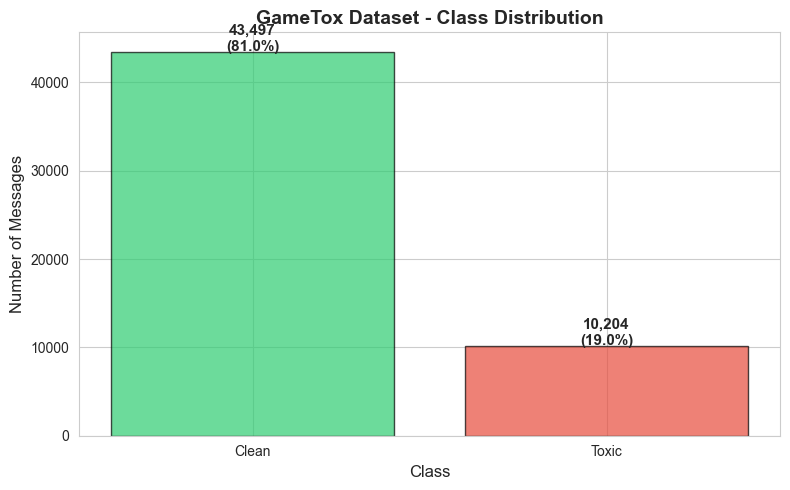


Dataset is imbalanced: 4.3x more clean than toxic
This is why we'll use F1-score (not accuracy) for evaluation.


In [5]:
# Visualize class distribution
labels_df = pd.DataFrame({'label': train_labels})
labels_df['label_name'] = labels_df['label'].map({0: 'Clean', 1: 'Toxic'})

plt.figure(figsize=(8, 5))
counts = labels_df['label_name'].value_counts()
colors = ['#2ecc71', '#e74c3c']  # green for clean, red for toxic
plt.bar(counts.index, counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('GameTox Dataset - Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Messages', fontsize=12)
plt.xlabel('Class', fontsize=12)

# Add count labels on bars
for i, (label, count) in enumerate(counts.items()):
    plt.text(i, count + 100, f'{count:,}\n({count/len(train_labels)*100:.1f}%)', 
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nDataset is imbalanced: {counts['Clean'] / counts['Toxic']:.1f}x more clean than toxic")
print(f"This is why we'll use F1-score (not accuracy) for evaluation.")

## 3. Load Test Set (Same as Level 2)

In [6]:
# Load the same 200-message test set used in Level 2
test_messages, test_labels = load_gametox('../data/test_subset_200_stratified.csv')

print(f"✓ Loaded {len(test_messages)} test messages (same as Level 2)")
print(f"\nTest set distribution:")
print(f"  Clean (0): {test_labels.count(0)} ({test_labels.count(0)/len(test_labels)*100:.1f}%)")
print(f"  Toxic (1): {test_labels.count(1)} ({test_labels.count(1)/len(test_labels)*100:.1f}%)")

print(f"\n" + "="*70)
print(f"IMPORTANT: We'll train on ALL GameTox data (including these 200 msgs)")
print(f"Then evaluate ONLY on these 200 to compare with Level 2 results.")
print(f"="*70)

✓ Loaded 200 test messages (same as Level 2)

Test set distribution:
  Clean (0): 163 (81.5%)
  Toxic (1): 37 (18.5%)

IMPORTANT: We'll train on ALL GameTox data (including these 200 msgs)
Then evaluate ONLY on these 200 to compare with Level 2 results.


## 4. Build ML Pipeline

We'll use a scikit-learn `Pipeline` that chains:
1. **TfidfVectorizer**: Convert text to numerical features
2. **LogisticRegression**: Train a classifier on those features

In [8]:
# Create pipeline with recommended settings from scikit-learn docs
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        sublinear_tf=True,      # Use sublinear TF scaling (1 + log(tf))
        max_df=0.5,             # Ignore terms in >50% of documents
        min_df=5,               # Ignore terms in <5 documents  
        stop_words='english',   # Remove common English words
        ngram_range=(1, 1)      # Use unigrams only (start simple)
    )),
    ('clf', LogisticRegression(
        max_iter=1000,          # Allow more iterations for convergence
        random_state=42,        # For reproducibility
        C=5,                    # Regularization strength (from sklearn docs)
        verbose=1               # Show training progress!
    ))
])

print("✓ Created ML pipeline:")
print("\nTF-IDF Settings:")
print(f"  - sublinear_tf: True (reduces impact of very frequent words)")
print(f"  - max_df: 0.5 (ignore words in >50% of docs)")
print(f"  - min_df: 5 (ignore rare words in <5 docs)")
print(f"  - stop_words: 'english' (remove common words like 'the', 'a')")
print(f"  - ngram_range: (1, 1) (single words only)")
print(f"\nLogistic Regression Settings:")
print(f"  - C: 5 (regularization strength)")
print(f"  - max_iter: 1000 (iterations to converge)")
print(f"  - verbose: 1 (show training progress)")

✓ Created ML pipeline:

TF-IDF Settings:
  - sublinear_tf: True (reduces impact of very frequent words)
  - max_df: 0.5 (ignore words in >50% of docs)
  - min_df: 5 (ignore rare words in <5 docs)
  - stop_words: 'english' (remove common words like 'the', 'a')
  - ngram_range: (1, 1) (single words only)

Logistic Regression Settings:
  - C: 5 (regularization strength)
  - max_iter: 1000 (iterations to converge)
  - verbose: 1 (show training progress)


## 5. Train the Model

In [9]:
print("Training ML model...")
print(f"Training data: {len(train_messages):,} messages")
print()

# Train and time it
start_time = time.time()
pipeline.fit(train_messages, train_labels)
train_time = time.time() - start_time

print(f"✓ Training complete!")
print(f"\nTraining time: {train_time:.2f}s")

# Show vocabulary size
vocab_size = len(pipeline.named_steps['tfidf'].vocabulary_)
print(f"\nLearned vocabulary:")
print(f"  - Total unique words (before filtering): ~{len(set(' '.join(train_messages).split())):,}")
print(f"  - Features after TF-IDF filtering: {vocab_size:,}")
print(f"  - Reduction: {(1 - vocab_size/len(set(' '.join(train_messages).split())))*100:.1f}%")

Training ML model...
Training data: 53,701 messages

✓ Training complete!

Training time: 0.32s

Learned vocabulary:
  - Total unique words (before filtering): ~24,708
  - Features after TF-IDF filtering: 2,388
  - Reduction: 90.3%


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished


## 6. What Did The Model Learn? (Feature Importance)

In [10]:
# Get feature names and their coefficients
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coefficients = pipeline.named_steps['clf'].coef_[0]

# Sort by coefficient (positive = toxic, negative = clean)
coef_df = pd.DataFrame({
    'word': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', ascending=False)

# Top words for TOXIC
print("=" * 70)
print("TOP 20 WORDS INDICATING TOXIC CONTENT")
print("=" * 70)
print(f"{'Rank':<6} {'Word':<20} {'Weight':>10}")
print("-" * 70)
for i, (_, row) in enumerate(coef_df.head(20).iterrows(), 1):
    print(f"{i:<6} {row['word']:<20} {row['coefficient']:>10.3f}")

print()
print("=" * 70)
print("TOP 20 WORDS INDICATING CLEAN CONTENT")
print("=" * 70)
print(f"{'Rank':<6} {'Word':<20} {'Weight':>10}")
print("-" * 70)
for i, (_, row) in enumerate(coef_df.tail(20).iloc[::-1].iterrows(), 1):
    print(f"{i:<6} {row['word']:<20} {row['coefficient']:>10.3f}")

TOP 20 WORDS INDICATING TOXIC CONTENT
Rank   Word                     Weight
----------------------------------------------------------------------
1      idiot                     7.759
2      fuck                      7.011
3      noob                      7.010
4      moron                     6.681
5      idiots                    6.638
6      fucking                   6.635
7      noobs                     6.398
8      apes                      6.367
9      loser                     6.347
10     braindead                 6.276
11     shit                      6.118
12     morons                    6.060
13     nobs                      6.052
14     cancer                    6.046
15     retard                    5.932
16     bullshit                  5.840
17     bot                       5.804
18     stfu                      5.648
19     idioti                    5.641
20     retarded                  5.637

TOP 20 WORDS INDICATING CLEAN CONTENT
Rank   Word                     W

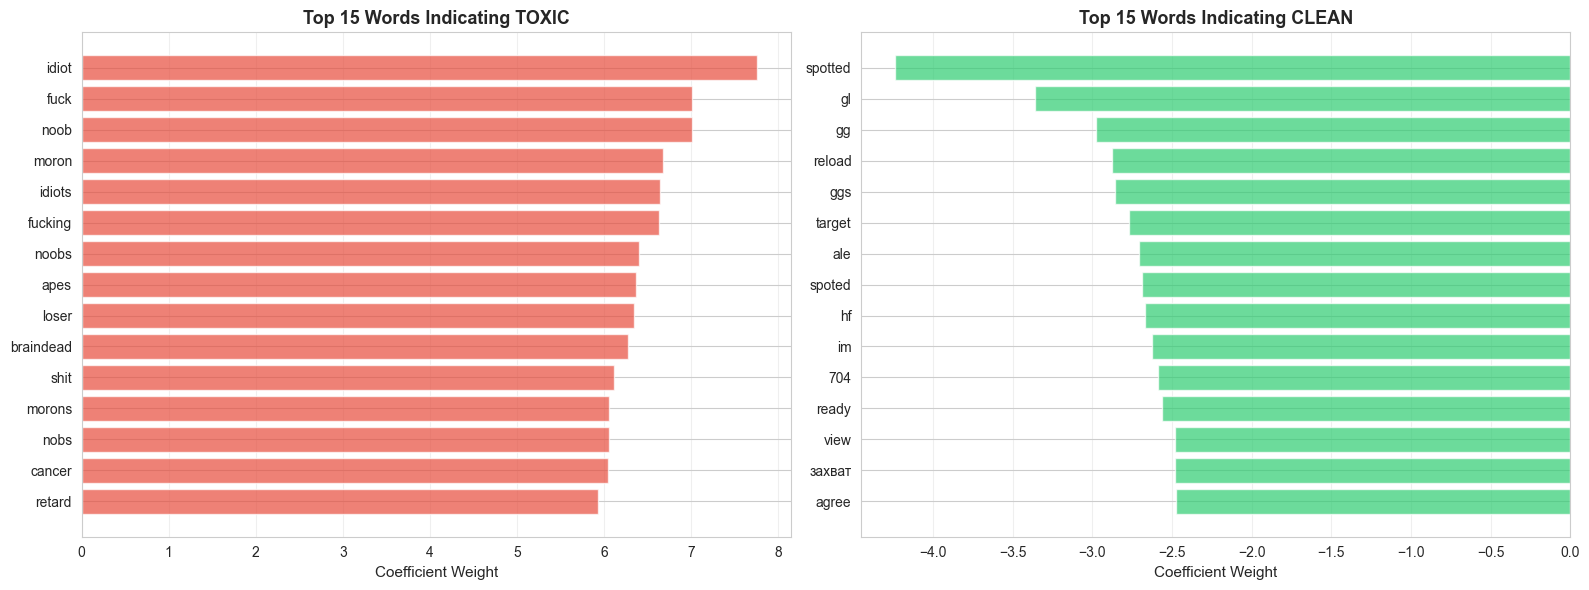


💡 Interpretation:
  - Positive weights → word indicates TOXIC content
  - Negative weights → word indicates CLEAN content
  - Larger magnitude = stronger indicator


In [11]:
# Visualize top features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top toxic words
top_toxic = coef_df.head(15)
axes[0].barh(range(len(top_toxic)), top_toxic['coefficient'].values, color='#e74c3c', alpha=0.7)
axes[0].set_yticks(range(len(top_toxic)))
axes[0].set_yticklabels(top_toxic['word'].values)
axes[0].invert_yaxis()
axes[0].set_xlabel('Coefficient Weight', fontsize=11)
axes[0].set_title('Top 15 Words Indicating TOXIC', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Top clean words
top_clean = coef_df.tail(15).iloc[::-1]
axes[1].barh(range(len(top_clean)), top_clean['coefficient'].values, color='#2ecc71', alpha=0.7)
axes[1].set_yticks(range(len(top_clean)))
axes[1].set_yticklabels(top_clean['word'].values)
axes[1].invert_yaxis()
axes[1].set_xlabel('Coefficient Weight', fontsize=11)
axes[1].set_title('Top 15 Words Indicating CLEAN', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("  - Positive weights → word indicates TOXIC content")
print("  - Negative weights → word indicates CLEAN content")
print("  - Larger magnitude = stronger indicator")

## 7. Evaluate on Test Set

In [12]:
print("Evaluating on test set (200 messages)...")
print()

# Predict and time it
start_time = time.time()
predictions = pipeline.predict(test_messages)
predict_time = time.time() - start_time

# Calculate metrics
accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions)
recall = recall_score(test_labels, predictions)
f1 = f1_score(test_labels, predictions)

print("=" * 70)
print("  LEVEL 3 (TRADITIONAL ML) - TEST SET PERFORMANCE")
print("=" * 70)
print()
print(f"Accuracy:   {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"Precision:  {precision:.3f} ({precision*100:.1f}%)")
print(f"Recall:     {recall:.3f} ({recall*100:.1f}%)")
print(f"F1-Score:   {f1:.3f}")
print()
print(f"Inference time: {predict_time*1000:.2f}ms for {len(test_messages)} messages")
print(f"Latency/msg:    {predict_time/len(test_messages)*1000:.2f}ms")
print()
print("=" * 70)

Evaluating on test set (200 messages)...

  LEVEL 3 (TRADITIONAL ML) - TEST SET PERFORMANCE

Accuracy:   0.900 (90.0%)
Precision:  0.840 (84.0%)
Recall:     0.568 (56.8%)
F1-Score:   0.677

Inference time: 7.05ms for 200 messages
Latency/msg:    0.04ms



In [13]:
# Detailed classification report
print("\nDetailed Classification Report:")
print()
print(classification_report(test_labels, predictions, 
                          target_names=['Clean', 'Toxic'],
                          digits=3))


Detailed Classification Report:

              precision    recall  f1-score   support

       Clean      0.909     0.975     0.941       163
       Toxic      0.840     0.568     0.677        37

    accuracy                          0.900       200
   macro avg      0.874     0.772     0.809       200
weighted avg      0.896     0.900     0.892       200



## 8. Confusion Matrix Visualization

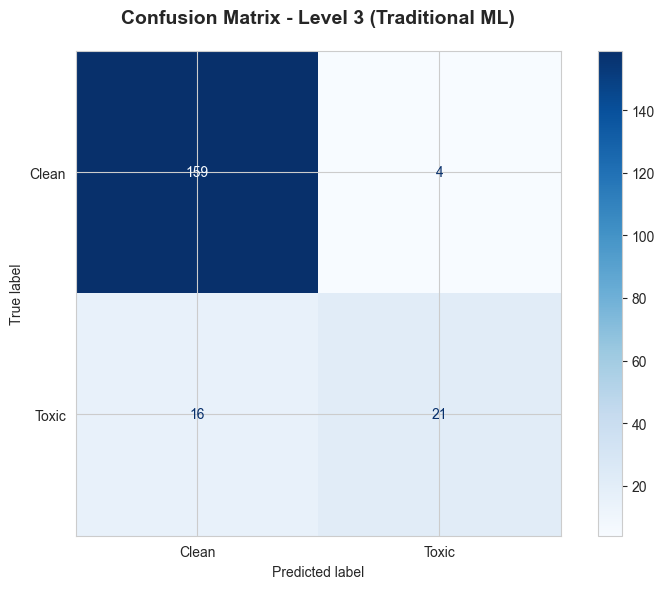


Confusion Matrix Breakdown:
  True Negatives (TN):  159 - Correctly identified as clean
  False Positives (FP):   4 - Clean messages flagged as toxic
  False Negatives (FN):  16 - Toxic messages missed
  True Positives (TP):   21 - Correctly identified as toxic

False Positive Rate: 2.5% (clean messages incorrectly flagged)
False Negative Rate: 43.2% (toxic messages missed)


In [14]:
# Create confusion matrix
cm = confusion_matrix(test_labels, predictions)

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clean', 'Toxic'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Level 3 (Traditional ML)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Explain the matrix
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {tn:3d} - Correctly identified as clean")
print(f"  False Positives (FP): {fp:3d} - Clean messages flagged as toxic")
print(f"  False Negatives (FN): {fn:3d} - Toxic messages missed")
print(f"  True Positives (TP):  {tp:3d} - Correctly identified as toxic")
print()
print(f"False Positive Rate: {fp/(fp+tn)*100:.1f}% (clean messages incorrectly flagged)")
print(f"False Negative Rate: {fn/(fn+tp)*100:.1f}% (toxic messages missed)")

## 9. Example Predictions with Confidence Scores

In [15]:
# Get prediction probabilities
proba = pipeline.predict_proba(test_messages)

# Show some examples
print("=" * 70)
print("  EXAMPLE PREDICTIONS WITH CONFIDENCE")
print("=" * 70)
print()

# Show first 20 predictions
for i in range(min(20, len(test_messages))):
    msg = test_messages[i]
    true_label = "TOXIC" if test_labels[i] == 1 else "CLEAN"
    pred_label = "TOXIC" if predictions[i] == 1 else "CLEAN"
    confidence = proba[i][predictions[i]] * 100
    
    # Determine correctness
    correct = "✓" if predictions[i] == test_labels[i] else "✗"
    
    # Format message
    msg_display = msg[:50] + "..." if len(msg) > 50 else msg
    
    print(f"{correct} \"{msg_display}\"")
    print(f"   True: {true_label:5s} | Pred: {pred_label:5s} ({confidence:.1f}% confident)")
    print()

# Show uncertain predictions (50-70% confidence)
uncertain_indices = [i for i, p in enumerate(proba) if 0.5 <= max(p) <= 0.7]
if uncertain_indices:
    print("\n" + "=" * 70)
    print("  UNCERTAIN PREDICTIONS (50-70% confidence)")
    print("=" * 70)
    print()
    
    for i in uncertain_indices[:10]:  # Show up to 10
        msg = test_messages[i]
        pred_label = "TOXIC" if predictions[i] == 1 else "CLEAN"
        confidence = proba[i][predictions[i]] * 100
        
        msg_display = msg[:60] + "..." if len(msg) > 60 else msg
        print(f"? \"{msg_display}\"")
        print(f"   Prediction: {pred_label} ({confidence:.1f}% confident)")
        print()

  EXAMPLE PREDICTIONS WITH CONFIDENCE

✓ "gg;)"
   True: CLEAN | Pred: CLEAN (99.5% confident)

✓ "do ciebie mam"
   True: CLEAN | Pred: CLEAN (92.7% confident)

✓ "going on crossfire"
   True: CLEAN | Pred: CLEAN (96.8% confident)

✓ "please"
   True: CLEAN | Pred: CLEAN (90.3% confident)

✓ "skorp"
   True: CLEAN | Pred: CLEAN (94.1% confident)

✓ "gg so far"
   True: CLEAN | Pred: CLEAN (99.1% confident)

✓ "qwou"
   True: CLEAN | Pred: CLEAN (90.3% confident)

✓ "i send replay for blocking"
   True: CLEAN | Pred: CLEAN (94.4% confident)

✓ "fucking focus"
   True: TOXIC | Pred: TOXIC (54.6% confident)

✓ "nothing to do waiting"
   True: CLEAN | Pred: CLEAN (77.9% confident)

✗ "*** you strv"
   True: TOXIC | Pred: CLEAN (90.3% confident)

✗ "jap"
   True: TOXIC | Pred: CLEAN (90.3% confident)

✓ "is back"
   True: CLEAN | Pred: CLEAN (90.3% confident)

✓ "Im Spotted at H9!"
   True: CLEAN | Pred: CLEAN (99.7% confident)

✓ "261 cap"
   True: CLEAN | Pred: CLEAN (97.7% confident)

✓

## 10. Compare with Level 1 and Level 2

In [16]:
# Results from other levels (you'll need to update these with actual values)
results = {
    'Level 1\n(Rule-Based)': {
        'F1-Score': 0.650,      # Update from Level 1 SUMMARY
        'Precision': 0.580,
        'Recall': 0.740,
        'Latency (ms)': 0.5,
        'Cost/1M msgs': 0
    },
    'Level 2\n(LLM)': {
        'F1-Score': 0.816,      # From Level 2 SUMMARY (Grok + Prompt V3)
        'Precision': 0.769,
        'Recall': 0.870,
        'Latency (ms)': 181,    # After caching optimization
        'Cost/1M msgs': 1710
    },
    'Level 3\n(Traditional ML)': {
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall,
        'Latency (ms)': predict_time/len(test_messages)*1000,
        'Cost/1M msgs': 0
    }
}

# Create comparison DataFrame
df = pd.DataFrame(results).T

print("=" * 80)
print("  CROSS-LEVEL COMPARISON")
print("=" * 80)
print()
print(df.to_string())
print()
print("=" * 80)

  CROSS-LEVEL COMPARISON

                           F1-Score  Precision    Recall  Latency (ms)  Cost/1M msgs
Level 1\n(Rule-Based)      0.650000      0.580  0.740000      0.500000           0.0
Level 2\n(LLM)             0.816000      0.769  0.870000    181.000000        1710.0
Level 3\n(Traditional ML)  0.677419      0.840  0.567568      0.035235           0.0



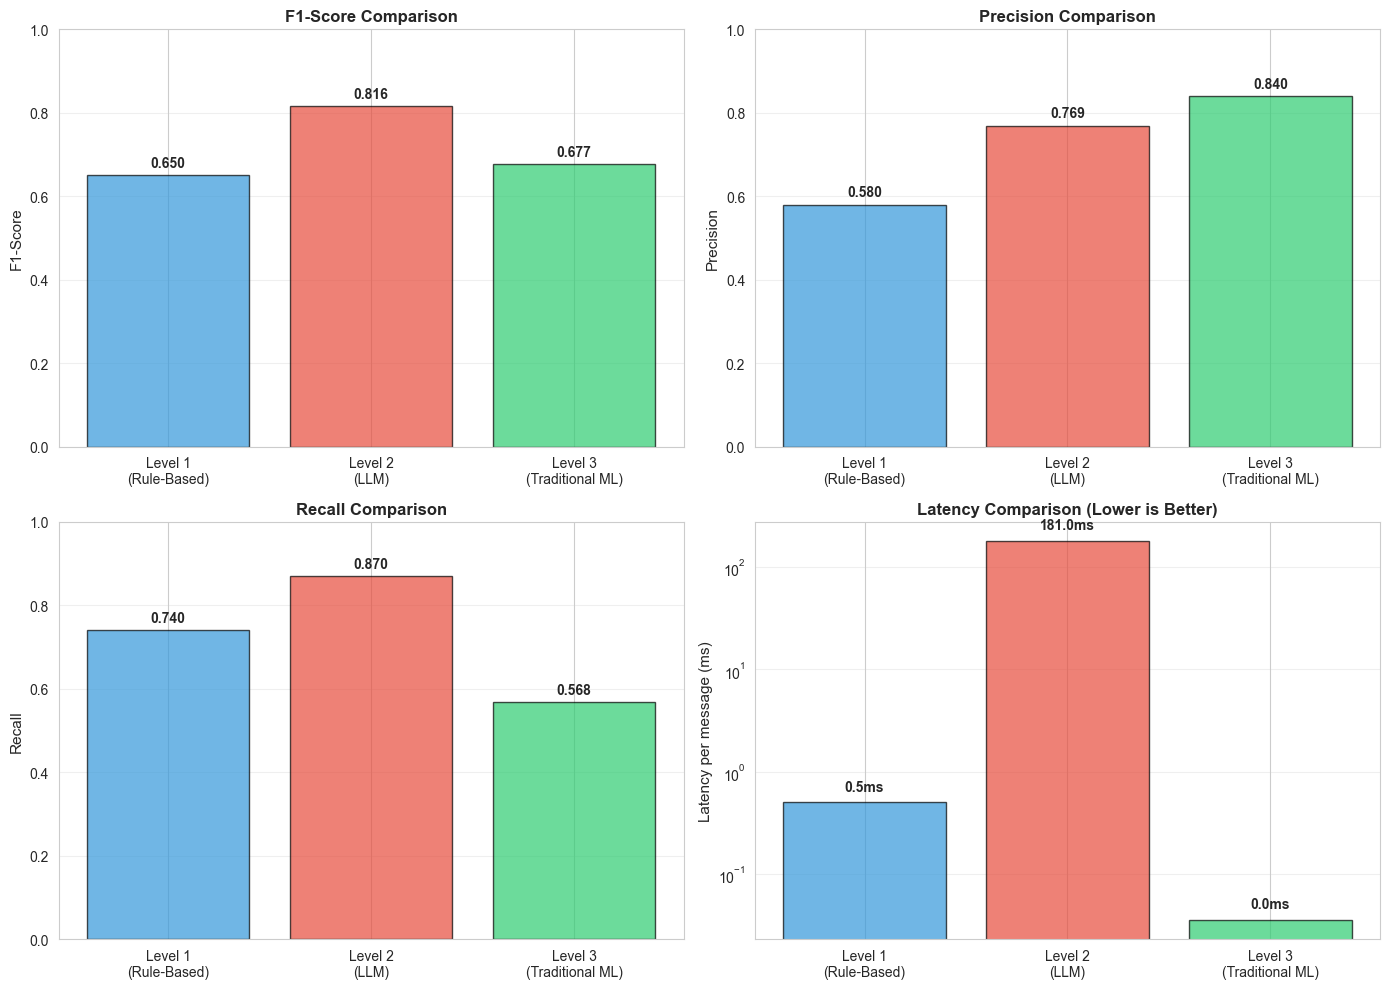

In [17]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

levels = list(results.keys())
colors = ['#3498db', '#e74c3c', '#2ecc71']

# F1-Score
f1_scores = [results[l]['F1-Score'] for l in levels]
axes[0, 0].bar(levels, f1_scores, color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('F1-Score', fontsize=11)
axes[0, 0].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(f1_scores):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Precision
precisions = [results[l]['Precision'] for l in levels]
axes[0, 1].bar(levels, precisions, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Precision', fontsize=11)
axes[0, 1].set_title('Precision Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(precisions):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Recall
recalls = [results[l]['Recall'] for l in levels]
axes[1, 0].bar(levels, recalls, color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Recall', fontsize=11)
axes[1, 0].set_title('Recall Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(recalls):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Latency (log scale for better visualization)
latencies = [results[l]['Latency (ms)'] for l in levels]
axes[1, 1].bar(levels, latencies, color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('Latency per message (ms)', fontsize=11)
axes[1, 1].set_title('Latency Comparison (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(latencies):
    axes[1, 1].text(i, v * 1.3, f'{v:.1f}ms', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 11. Key Takeaways

### What We Learned:

1. **Traditional ML is the middle ground:**
   - Better accuracy than rules (Level 1)
   - Lower cost and latency than LLMs (Level 2)
   - Requires training data (unlike rules or pre-trained LLMs)

2. **Training is fast and local:**
   - Trained in seconds on your laptop
   - No cloud APIs or costs
   - Model can be saved and reused

3. **Predictions are instant:**
   - Much faster than LLM API calls
   - Can process thousands of messages per second
   - No network latency

4. **Model is interpretable:**
   - Can see which words indicate toxic vs clean
   - Understand why predictions are made
   - Can debug and improve based on learned features

5. **Tradeoffs exist:**
   - Needs labeled training data
   - May struggle with context ("that's sick!" = positive)
   - Requires retraining to adapt to new patterns

### When to Use Traditional ML:
- You have labeled training data
- Cost and latency matter
- Offline/local deployment needed
- Interpretability is important
- Production scale (millions of messages/day)

## 12. Save the Model

In [18]:
# Save the trained pipeline
model_path = 'profanity_classifier.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(pipeline, f)

print(f"✓ Model saved to {model_path}")
print()
print("To use in production:")
print("```python")
print("import pickle")
print("")
print("# Load model")
print("with open('profanity_classifier.pkl', 'rb') as f:")
print("    model = pickle.load(f)")
print("")
print("# Predict")
print("prediction = model.predict(['new message here'])[0]")
print("print('Toxic' if prediction == 1 else 'Clean')")
print("```")

✓ Model saved to profanity_classifier.pkl

To use in production:
```python
import pickle

# Load model
with open('profanity_classifier.pkl', 'rb') as f:
    model = pickle.load(f)

# Predict
prediction = model.predict(['new message here'])[0]
print('Toxic' if prediction == 1 else 'Clean')
```
